# Processing ISS Radiosonde Data

This notebook evaluates whether the M2HATS ISS1 radiosonde soundings (Vaisala RS41, Aspen-QC'd NetCDF) should be converted to a Zarr store or kept as NetCDF, and writes the GDEX copy. It inventories the files, builds a combined campaign-wide dataset, benchmarks it against the source NetCDF, and records the decision: **keep one NetCDF file per sounding**. The GDEX copy corrects the descent timestamps and renames variables to match the ISFS Zarr stores, using [`code/m2hats_radiosonde.py`](../../code/m2hats_radiosonde.py). The dataset is small (58 MB), so no Dask cluster is needed.

**Workflow:**
1. **Setup** — imports and paths
2. **Inspect one file** — structure, variables, and per-sounding metadata
3. **Inventory the campaign** — consistency checks across all 237 files
4. **Build a combined DataTree** — every sounding stacked on `(launch_time, elapsed)`, with `/ascent` and `/descent` groups
5. **Zarr format evaluation** — size and read latency versus the source NetCDF
6. **Decision and GDEX write** — keep NetCDF; write corrected, ISFS-named files
7. **Example analysis** — morning vs afternoon boundary-layer profiles

**Input:** `FDA_datasets/ISS_radiosonde/*.nc`  
**Output:** `GDEX_datasets/iss1_m2hats_rs41_radiosonde/*.nc` (and `WORKING_datasets/iss1_m2hats_rs41_radiosonde.zarr`, the Stage 5 evaluation copy)

## Stage 1: Setup

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "/glade/u/home/myasears/m2hats-in-gdex/code")  # m2hats_radiosonde.py lives in code/
import m2hats_radiosonde as rs

# Source radiosonde NetCDF files (one per ascent or descent)
rs_path = Path("/lustre/desc1/scratch/myasears/M2HATS/FDA_datasets/ISS_radiosonde")

# Evaluation Zarr store (Stage 5) and the corrected NetCDF files for GDEX (Stage 6)
working_zarr = "/lustre/desc1/scratch/myasears/M2HATS/WORKING_datasets/iss1_m2hats_rs41_radiosonde.zarr"
gdex_dir     = Path("/lustre/desc1/scratch/myasears/M2HATS/GDEX_datasets/iss1_m2hats_rs41_radiosonde")

def dir_size_mb(path):
    return sum(f.stat().st_size for f in Path(path).rglob("*") if f.is_file()) / 1e6

## Stage 2: Inspect one file

Each file is one CF `trajectory`: a 1 Hz time series along the balloon path (`lat`, `lon`, `gpsalt` are coordinates), a single surface reference observation on the `obs` dimension, and about 50 global attributes describing the sounding (sonde ID, ground-check corrections, termination reason). Missing values are `-999`, which xarray converts to NaN on read.

In [2]:
sample = xr.open_dataset(rs_path / "NCAR_M2HATS_ISS1_RS41_v1_20230814_165849_asc.nc")
sample

<xarray.Dataset> Size: 422kB
Dimensions:         (time: 5024, obs: 1)
Coordinates:
  * time            (time) datetime64[ns] 40kB 2023-08-14T16:58:49 ... 2023-0...
    lat             (time) float32 20kB ...
    lon             (time) float32 20kB ...
    gpsalt          (time) float32 20kB ...
Dimensions without coordinates: obs
Data variables: (12/27)
    trajectory      |S1 1B ...
    launch_time     datetime64[ns] 8B ...
    pres            (time) float32 20kB ...
    tdry            (time) float32 20kB ...
    dp              (time) float32 20kB ...
    rh              (time) float32 20kB ...
    ...              ...
    reference_rh    (obs) float32 4B ...
    reference_wspd  (obs) float32 4B ...
    reference_wdir  (obs) float32 4B ...
    reference_lat   (obs) float32 4B ...
    reference_lon   (obs) float32 4B ...
    reference_alt   (obs) float32 4B ...
Attributes: (12/50)
    Conventions:                           CF-1.6
    RepoRevision:                          V3.4.7
    RepoLastChangedDate:                   Fri May 6 14:29:37 2022 -0600
    RepoId:                                14c38ba5b54ddaa3e2c5c0669fd4f5b756...
    RepoBranch:                            HEAD
    featureType:                           trajectory
    ...                                    ...
    TerminatingAltitude:                   21939 m
    TrackedSatelliteAverageCount:          10.6
    TrefTemperature:                       /////
    TuTemperature:                         21.06 �C
    UCorrection(Uref1-U1):                 -0.04 %Rh
    Uref1Humidity:                         0.00 %Rh

## Stage 3: Inventory the campaign

File names encode the launch time and whether the file is an ascent (`_asc`) or descent (`_dsc`). Descent records begin at balloon burst and usually end when the signal is lost, so they are shorter and more variable. The checks confirm that every file has the same variables and units and increasing time on a 1-second grid (a few soundings have short gaps), which is what makes a combined store possible.

In [3]:
rows, layouts = [], set()
for f in sorted(rs_path.glob("*.nc")):
    with xr.open_dataset(f) as ds:
        dt = np.diff(ds.time.values) / np.timedelta64(1, "s")
        layouts.add(tuple((v, ds[v].attrs.get("units")) for v in sorted(ds.variables)))
        rows.append({
            "launch_time": ds.launch_time.values,
            "kind": f.stem.split("_")[-1],
            "samples": ds.sizes["time"],
            "minutes": ds.sizes["time"] / 60,
            "top_km": float(ds.gpsalt.max()) / 1e3,
            "max_step_s": dt.max() if dt.size else 1,
            "termination": ds.attrs["ReasonForTermination"],
        })
inventory = pd.DataFrame(rows)

gaps = inventory.query("max_step_s > 1")
print(f"{len(inventory)} files, {len(layouts)} distinct variable/unit layout(s); "
      f"{len(gaps)} soundings have gaps (longest {gaps.max_step_s.max():.0f} s), all others are gap-free 1 Hz")
launches = inventory.query("kind == 'asc'").launch_time
print(f"{len(launches)} launches, {launches.min()} → {launches.max()}")
print(inventory.groupby("kind")[["samples", "minutes", "top_km"]].describe().T.round(1).loc[(slice(None), ["count", "min", "50%", "max"]), :])
print("\nAscent launch hours (UTC):", inventory.query("kind == 'asc'").launch_time.dt.hour.value_counts().sort_index().to_dict())
print("Termination reasons:", inventory.termination.value_counts().to_dict())

237 files, 1 distinct variable/unit layout(s); 32 soundings have gaps (longest 14 s), all others are gap-free 1 Hz
122 launches, 2023-07-19 16:13:44 → 2023-09-25 16:33:44
kind              asc     dsc
samples count   122.0   115.0
        min    1536.0    17.0
        50%    5121.5   647.0
        max    6143.0  2489.0
minutes count   122.0   115.0
        min      25.6     0.3
        50%      85.4    10.8
        max     102.4    41.5
top_km  count   122.0   115.0
        min      10.2    15.0
        50%      22.5    22.5
        max      25.3    25.1

Ascent launch hours (UTC): {4: 1, 16: 25, 17: 35, 21: 23, 22: 38}
Termination reasons: {'IncreasingPressure': 234, 'HumiditySensorFailure': 2, 'ExcessiveMissingGpsHeight': 1}


### Descent timestamps are offset in the source files

Each descent file starts at balloon burst, at the same altitude where its ascent ended. Its `time` values, however, are seconds since **launch** stored against a reference time of **burst** (the descent's `launch_time` attribute and units are the burst time). As a result, every descent timestamp in the source NetCDF is late by the length of its ascent. The check below shows this for every descent: the gap between the end of the ascent and the start of the descent equals the ascent's duration, even though the altitude is continuous. This should be reported to EOL. Stage 4 corrects it in the combined evaluation dataset, and Stage 6 corrects it in the GDEX files by re-referencing the time units to launch.

In [4]:
checks = []
for f in sorted(rs_path.glob("*_dsc.nc")):
    with xr.open_dataset(f) as d, xr.open_dataset(str(f).replace("_dsc", "_asc")) as a:
        checks.append({"gap_min":    float((d.time[0] - a.time[-1]) / np.timedelta64(60, "s")),
                       "ascent_min": float((a.time[-1] - a.time[0]) / np.timedelta64(60, "s")),
                       "alt_jump_m": float(d.gpsalt[0] - a.gpsalt[-1])})
checks = pd.DataFrame(checks)
print(f"{len(checks)} descents start {checks.gap_min.min():.0f}–{checks.gap_min.max():.0f} min after their ascent ends,")
print(f"but within {checks.alt_jump_m.abs().max():.0f} m of the ascent's final altitude.")
print(f"Gap minus ascent duration: at most {(checks.gap_min - checks.ascent_min).abs().max() * 60:.0f} s")

115 descents start 57–102 min after their ascent ends,
but within 19 m of the ascent's final altitude.
Gap minus ascent duration: at most 18 s


## Stage 4: Build a combined DataTree

Descents are indexed by their ascent's launch time and their `time` is re-referenced to that launch (see Stage 3), so ascents and descents line up. Soundings differ in length, so each is placed on a shared `elapsed` axis (seconds since the first sample: launch for ascents, burst for descents) and shorter soundings are NaN-padded. `launch_time` becomes the sounding dimension, so `tree["/ascent"].ds.sel(launch_time="2023-08-14")` selects that day's ascents. The surface reference observation and a few per-sounding attributes become variables on `launch_time`. Global attributes that are the same for every sounding are kept, and those that vary per sounding are dropped (the source files keep them).

In [5]:
META_ATTRS = ["SondeId", "SondeType", "ReasonForTermination", "TerminatingAltitude", "SoundingLength"]

def load_soundings(kind):
    """Stack every `kind` ('asc' or 'dsc') sounding on (launch_time, elapsed)."""
    soundings = []
    for f in sorted(rs_path.glob(f"*_{kind}.nc")):
        with xr.open_dataset(f) as ds:
            if kind == "dsc":   # re-reference descent times from burst to launch (Stage 3)
                launch = xr.open_dataset(str(f).replace("_dsc", "_asc")).launch_time
                ds = ds.assign_coords(time=launch.values + (ds.time - ds.launch_time).values).assign(launch_time=launch)
                ds.time.attrs["comment"] = ("Corrected: source descent times are seconds since launch "
                                            "but referenced to burst; re-referenced to the ascent launch time.")
            elapsed = ((ds.time - ds.time[0]) / np.timedelta64(1, "s")).astype("int32").values
            ds = (ds.drop_vars("trajectory").squeeze("obs", drop=True)
                    .assign_coords(elapsed=("time", elapsed)).swap_dims(time="elapsed")
                    .reset_coords(["time", "lat", "lon", "gpsalt"])
                    .assign({k: ((), np.array(ds.attrs.get(k, ""), dtype=object)) for k in META_ATTRS})
                    .set_coords("launch_time").expand_dims("launch_time")
                    .set_coords(["time", "lat", "lon", "gpsalt"]))
            soundings.append(ds.load())
    out = xr.concat(soundings, "launch_time", join="outer", coords="minimal", combine_attrs="drop_conflicts")
    out["elapsed"].attrs = {"units": "s", "long_name": "Seconds since first sample (launch for ascents, burst for descents)"}
    return out

t0 = time.perf_counter()
tree = xr.DataTree.from_dict({"/ascent": load_soundings("asc"), "/descent": load_soundings("dsc")})
t_combine = time.perf_counter() - t0
print(f"Built from {len(inventory)} NetCDF files in {t_combine:.1f} s")
tree

Built from 237 NetCDF files in 3.2 s


<xarray.DataTree>
Group: /
├── Group: /ascent
│       Dimensions:               (launch_time: 122, elapsed: 6143)
│       Coordinates:
│         * launch_time           (launch_time) datetime64[ns] 976B 2023-07-19T16:13:...
│         * elapsed               (elapsed) int32 25kB 0 1 2 3 4 ... 6139 6140 6141 6142
│           time                  (launch_time, elapsed) datetime64[ns] 6MB 2023-07-1...
│           lat                   (launch_time, elapsed) float32 3MB 38.04 38.04 ... nan
│           lon                   (launch_time, elapsed) float32 3MB -117.1 ... nan
│           gpsalt                (launch_time, elapsed) float32 3MB 1.641e+03 ... nan
│       Data variables: (12/30)
│           pres                  (launch_time, elapsed) float32 3MB 842.2 840.6 ... nan
│           tdry                  (launch_time, elapsed) float32 3MB 23.9 23.9 ... nan
│           dp                    (launch_time, elapsed) float32 3MB 11.3 10.8 ... nan
│           rh                    (launch_time, elapsed) float32 3MB 45.1 43.77 ... nan
│           u_wind                (launch_time, elapsed) float32 3MB 9.873 10.79 ... nan
│           v_wind                (launch_time, elapsed) float32 3MB -5.7 -6.508 ... nan
│           ...                    ...
│           reference_alt         (launch_time) float32 488B 1.641e+03 ... 1.641e+03
│           SondeId               (launch_time) object 976B 'P0950520' ... 'V1241410'
│           SondeType             (launch_time) object 976B 'RS41-SGP' ... 'RS41-SGP'
│           ReasonForTermination  (launch_time) object 976B 'IncreasingPressure' ... ...
│           TerminatingAltitude   (launch_time) object 976B '22123 m' ... '23308 m'
│           SoundingLength        (launch_time) object 976B '01:19:08 hh:mm:ss' ... '...
│       Attributes: (12/27)
│           Conventions:                           CF-1.6
│           RepoRevision:                          V3.4.7
│           RepoLastChangedDate:                   Fri May 6 14:29:37 2022 -0600
│           RepoId:                                14c38ba5b54ddaa3e2c5c0669fd4f5b756...
│           RepoBranch:                            HEAD
│           featureType:                           trajectory
│           ...                                    ...
│           SoundingStatus:                        Ok
│           StationName:                           M2HATS_ISS1
│           SurfaceDataNote:                       Timeseries data point at launch (t...
│           SystemTrademarkAndModel:               MW41
│           TrefTemperature:                       /////
│           Uref1Humidity:                         0.00 %Rh
└── Group: /descent
        Dimensions:               (launch_time: 115, elapsed: 2489)
        Coordinates:
          * launch_time           (launch_time) datetime64[ns] 920B 2023-07-19T16:13:...
          * elapsed               (elapsed) int32 10kB 0 1 2 3 4 ... 2485 2486 2487 2488
            lat                   (launch_time, elapsed) float32 1MB 38.39 38.39 ... nan
            lon                   (launch_time, elapsed) float32 1MB -116.7 ... nan
            gpsalt                (launch_time, elapsed) float32 1MB 2.203e+04 ... nan
            time                  (launch_time, elapsed) datetime64[ns] 2MB 2023-07-1...
        Data variables: (12/30)
            pres                  (launch_time, elapsed) float32 1MB 41.96 42.03 ... nan
            tdry                  (launch_time, elapsed) float32 1MB -56.9 -56.9 ... nan
            dp                    (launch_time, elapsed) float32 1MB -85.7 -85.7 ... nan
            rh                    (launch_time, elapsed) float32 1MB 1.68 1.67 ... nan
            u_wind                (launch_time, elapsed) float32 1MB -13.09 ... nan
            v_wind                (launch_time, elapsed) float32 1MB -0.3886 ... nan
            ...                    ...
            reference_alt         (launch_time) float32 460B 2.203e+04 ... 2.334e+04
            SondeId               (lau

## Stage 5: Zarr format evaluation

The same three measures as the ISFS 5-minute evaluation: size on disk, time to get the whole campaign into memory, and time for a cross-sounding slice (one variable at one elapsed time for every ascent). Padding is the fraction of the combined ascent array that holds no data.

In [6]:
tree.to_zarr(working_zarr, mode="w", consolidated=True)

t0 = time.perf_counter()
z = xr.open_datatree(working_zarr, engine="zarr").load()
t_zarr_all = time.perf_counter() - t0

asc_files = sorted(rs_path.glob("*_asc.nc"))
t0 = time.perf_counter()
_ = [xr.open_dataset(f).tdry.isel(time=600).load() for f in asc_files if xr.open_dataset(f).sizes["time"] > 600]
t_nc_slice = time.perf_counter() - t0
t0 = time.perf_counter()
_ = xr.open_datatree(working_zarr, engine="zarr")["/ascent"].ds.tdry.sel(elapsed=600).load()
t_zarr_slice = time.perf_counter() - t0

nc_mb = sum(f.stat().st_size for f in rs_path.glob("*.nc")) / 1e6
padding = float(tree["/ascent"].ds.tdry.isnull().mean())
print(f"Size          : NetCDF {nc_mb:5.1f} MB in {len(inventory)} files | Zarr {dir_size_mb(working_zarr):5.1f} MB")
print(f"Whole campaign: NetCDF {t_combine:5.2f} s (open + combine) | Zarr {t_zarr_all:5.2f} s")
print(f"Slice (tdry at 600 s, all ascents): NetCDF {t_nc_slice:5.2f} s | Zarr {t_zarr_slice:5.2f} s")
print(f"Ascent array padding/missing: {padding:.0%}")

Size          : NetCDF  59.9 MB in 237 files | Zarr  28.6 MB
Whole campaign: NetCDF  3.15 s (open + combine) | Zarr  0.20 s
Slice (tdry at 600 s, all ascents): NetCDF  0.90 s | Zarr  0.06 s
Ascent array padding/missing: 18%


## Stage 6: Decision and GDEX write

**Decision: keep the radiosondes as one NetCDF file per sounding; no Zarr store is published.**

| Consideration | Source NetCDF (237 files) | Combined Zarr |
|---|---|---|
| Size | 58 MB | about half, but both are trivially small |
| Whole-campaign access | 2–15 s to open and combine, depending on file-system caching (Stage 4) | about 0.2 s |
| Single-sounding access | instant, one file per launch | instant |
| Format familiarity | standard per-sounding CF trajectory from Aspen, the form radiosonde users and tools expect | project-specific layout that users must learn |
| Metadata | all ~50 per-sounding attributes (ground-check corrections, sonde IDs) | per-sounding attributes must be flattened; most are dropped here |
| Structure | natural: one trajectory per file | ragged soundings padded to a common length (about 20% padding for ascents) |

The Zarr's only real gain is saving a few seconds once per session for whole-campaign work, and that is easy to get from the NetCDF with the `load_soundings` function above. Unlike the 250 GB high-rate ISFS data, there is no chunked-access or size problem for Zarr to solve, and converting would trade away the standard format and some metadata. Moving the files from on-prem storage to GDEX still gives the accessibility benefit.

The descent timestamp offset (Stage 3) is in the FDA source files and should still be reported to EOL; the GDEX copy written below is corrected.

A Zarr would become worthwhile if GDEX needed one consistent format across all M2HATS datasets, or if users routinely combined soundings with the ISFS stores.

### Write the GDEX copy

`rs.convert_all` writes one file per source file with the same file name, as zlib-compressed NetCDF-4 (the source is NetCDF-3 Classic), making two changes:
- **Descent timing:** `time`, `launch_time`, `reference_time` and the `BalloonRelease*` attributes of each descent are re-referenced from burst to the launch time of the matching ascent. The stored values are unchanged.
- **Variable names and units** match the ISFS Zarr stores (e.g. `tdry` → `air_temperature`, `u_wind` → `wind_u`, `degC` → `degree_C`, `m/s` → `m s-1`). The source name and units are kept in each variable's `source_short_name` and `source_units` attributes.

The check confirms no data values changed and every descent now begins within seconds of its ascent's end.

In [7]:
written = rs.convert_all(rs_path, gdex_dir)

changed, lag_s = [], []
for out in written:
    src, new = xr.open_dataset(rs_path / out.name), xr.open_dataset(out)
    if not all(np.array_equal(src[s].values, new[o].values, equal_nan=True)
               for s, (o, _, _) in rs.RS_VAR_METADATA.items() if s in src):
        changed.append(out.name)
    if out.stem.endswith("_dsc"):
        asc = xr.open_dataset(gdex_dir / out.name.replace("_dsc", "_asc"))
        lag_s.append(float((new.time[0] - asc.time[-1]) / np.timedelta64(1, "s")))

print(f"Wrote {len(written)} files ({dir_size_mb(gdex_dir):.0f} MB) to {gdex_dir}")
print(f"Files with changed data values: {len(changed)}")
print(f"Descents now start {min(lag_s):.0f}–{max(lag_s):.0f} s after their ascent ends")
print("Variables:", list(new.data_vars))

Wrote 237 files (57 MB) to /lustre/desc1/scratch/myasears/M2HATS/GDEX_datasets/iss1_m2hats_rs41_radiosonde
Files with changed data values: 0
Descents now start 1–5 s after their ascent ends
Variables: ['trajectory', 'launch_time', 'air_pressure', 'air_temperature', 'dew_point_temperature', 'relative_humidity', 'wind_u', 'wind_v', 'wind_w', 'wind_speed', 'wind_from_direction', 'sonde_vertical_velocity', 'humidity_mixing_ratio', 'virtual_temperature', 'potential_temperature', 'equivalent_potential_temperature', 'virtual_potential_temperature', 'altitude', 'reference_time', 'reference_air_pressure', 'reference_air_temperature', 'reference_relative_humidity', 'reference_wind_speed', 'reference_wind_from_direction', 'reference_latitude', 'reference_longitude', 'reference_altitude']


## Stage 7: Example analysis

With every ascent on one array, campaign-wide comparisons take a few lines. Here, potential temperature profiles in the lowest 5 km for morning launches (16–17 UTC, 09–10 PDT) and afternoon launches (21–22 UTC, 14–15 PDT) show the deep, well-mixed afternoon boundary layer typical of the Nevada desert in summer.

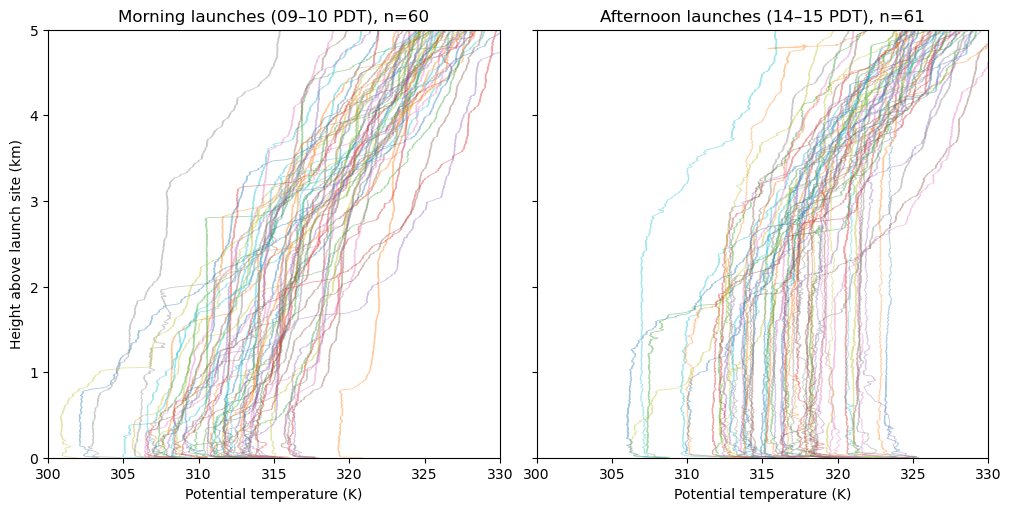

In [8]:
asc = tree["/ascent"].ds
hour = asc.launch_time.dt.hour
groups = {"Morning launches (09–10 PDT)": hour.isin([16, 17]),
          "Afternoon launches (14–15 PDT)": hour.isin([21, 22])}

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True, layout="constrained")
for ax, (label, sel) in zip(axes, groups.items()):
    s = asc.sel(launch_time=sel)
    height_km = (s.alt - s.reference_alt) / 1e3              # height above the launch site
    ax.plot(s.theta.T, height_km.T, lw=0.6, alpha=0.4)
    ax.set(title=f"{label}, n={s.sizes['launch_time']}", xlabel="Potential temperature (K)",
           xlim=(300, 330), ylim=(0, 5))
axes[0].set_ylabel("Height above launch site (km)");